In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)
normal_salaries = np.random.normal(loc=50000, scale=10000, size=100)
outliers  = np.array([250000, 300000, 15000])

data = pd.DataFrame({"Salary" : np.concatenate([normal_salaries, outliers])})


In [8]:
print("Dataset Summary before clearning:")
print(data.describe())

Dataset Summary before clearning:
              Salary
count     103.000000
mean    53020.907598
std     32997.043394
min     15000.000000
25%     43988.273489
50%     48843.517176
75%     55049.907931
max    300000.000000


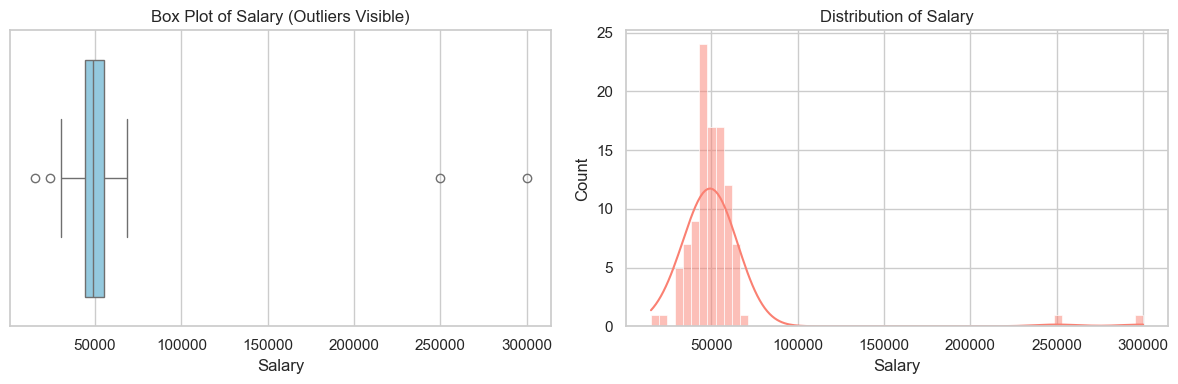

In [21]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=data, x="Salary", ax=axes[0], color="skyblue")
axes[0].set_title('Box Plot of Salary (Outliers Visible)')

sns.histplot(data["Salary"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title('Distribution of Salary')

plt.tight_layout()
plt.show()


In [25]:
# detect outliers using IQR
Q1 = data["Salary"].quantile(0.25)
Q3 = data["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q1 + 1.5 * IQR

In [30]:
print(f"\nQ1 (25th percentile) : {Q1:.2f}")
print(f"Q3 (75th percentile) : {Q3:.2f}")
print(f"IQR : {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")


Q1 (25th percentile) : 43988.27
Q3 (75th percentile) : 55049.91
IQR : 11061.63
Lower Bound: 27395.82
Upper Bound: 60580.73


In [33]:
# Identify outlier rows
outliers_rows = data[(data["Salary"] < lower_bound) | (data["Salary"] > upper_bound)]
print(f"\nDetected {len(outliers_rows)} Outliers")
print(outliers_rows)


Detected 12 Outliers
            Salary
3     65230.298564
6     65792.128155
20    64656.487689
31    68522.781845
65    63562.400286
71    65380.365665
73    65646.436558
74    23802.548959
82    64778.940447
100  250000.000000
101  300000.000000
102   15000.000000


In [38]:
df_cleaned = data[(data["Salary"] >= lower_bound) & (data["Salary"] <= upper_bound)]

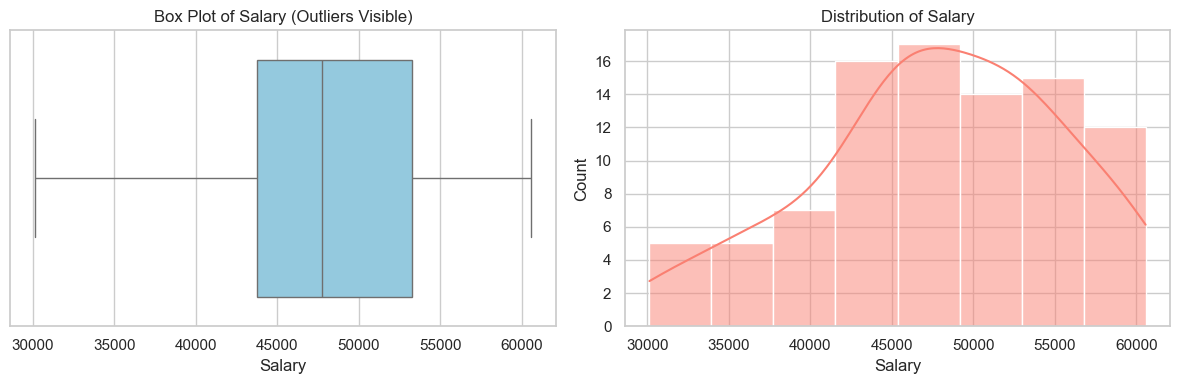

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df_cleaned, x="Salary", ax=axes[0], color="skyblue")
axes[0].set_title('Box Plot of Salary (Outliers Visible)')

sns.histplot(df_cleaned["Salary"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title('Distribution of Salary')

plt.tight_layout()
plt.show()


In [40]:
print("\nDataset Summary after cleaning:")
print(df_cleaned.describe())


Dataset Summary after cleaning:
             Salary
count     91.000000
mean   47788.803236
std     7614.926944
min    30124.310854
25%    43765.868166
50%    47742.236995
75%    53300.072705
max    60571.222262


# Comeplete Model Pipeline

In [42]:
import numpy as np
import pandas as np


### 1. Create a simple practice dataset

In [43]:
data = pd.DataFrame({
    'Age': [22, 38, 26, 35, 48, 52, 21, 30, 42, 55],
    'Salary': [25000, 60000, 32000, 52000, 90000, 110000, 22000, 45000, 85000, 120000],
    'Gender': ['Female', 'Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'Purchased': [0, 1, 0, 1, 1, 1, 0, 0, 1, 1]  # Target: 0 = No, 1 = Yes
})

In [45]:
X = data[['Age', 'Salary', 'Gender']]
y = data['Purchased']

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

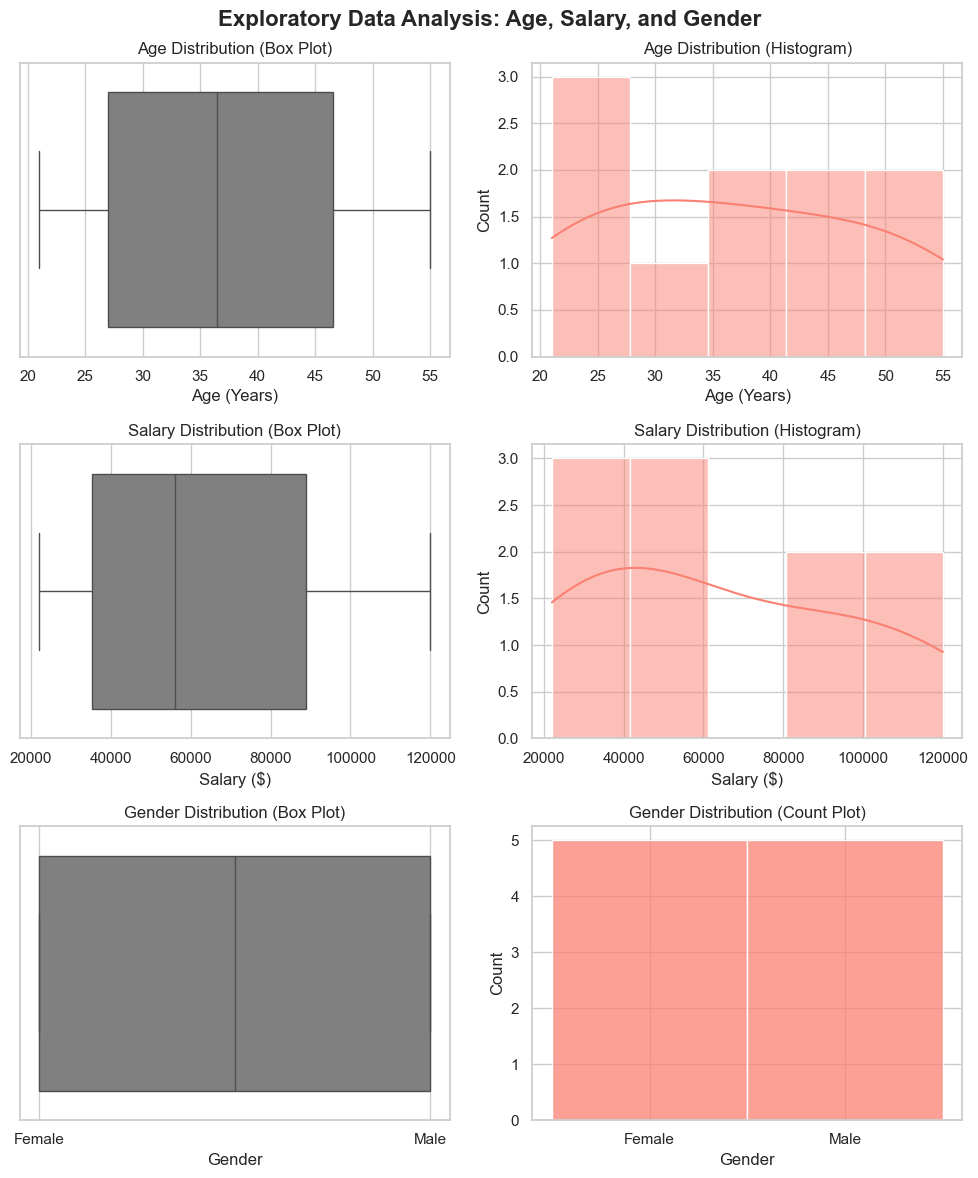

In [63]:
# 1. Create the grid setup
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
flat_axes = axes.flatten()

# --- ROW 1: AGE DISTRIBUTION ---
sns.boxplot(data=data, x="Age", ax=flat_axes[0], color="gray")
flat_axes[0].set_title("Age Distribution (Box Plot)")
flat_axes[0].set_xlabel("Age (Years)")

sns.histplot(data=data, x="Age", kde=True, ax=flat_axes[1], color="salmon")
flat_axes[1].set_title("Age Distribution (Histogram)")
flat_axes[1].set_xlabel("Age (Years)")
flat_axes[1].set_ylabel("Count")

# --- ROW 2: SALARY DISTRIBUTION ---
sns.boxplot(data=data, x="Salary", ax=flat_axes[2], color="gray")
flat_axes[2].set_title("Salary Distribution (Box Plot)")
flat_axes[2].set_xlabel("Salary ($)")

sns.histplot(data=data, x="Salary", kde=True, ax=flat_axes[3], color="salmon")
flat_axes[3].set_title("Salary Distribution (Histogram)")
flat_axes[3].set_xlabel("Salary ($)")
flat_axes[3].set_ylabel("Count")

# --- ROW 3: GENDER DISTRIBUTION ---
sns.boxplot(data=data, x="Gender", ax=flat_axes[4], color="gray")
flat_axes[4].set_title("Gender Distribution (Box Plot)")
flat_axes[4].set_xlabel("Gender")

sns.histplot(data=data, x="Gender", kde=False, ax=flat_axes[5], color="salmon") # Removed kde=True for categorical data
flat_axes[5].set_title("Gender Distribution (Count Plot)")
flat_axes[5].set_xlabel("Gender")
flat_axes[5].set_ylabel("Count")

# 2. Add an overall figure title
fig.suptitle("Exploratory Data Analysis: Age, Salary, and Gender", fontsize=16, fontweight='bold', y=0.98)

# 3. Clean up spacing to prevent overlaps
plt.tight_layout()
plt.show()

In [66]:
numerical_features = ["Age", "Salary"]
categorical_features = ["Gender"]


In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [78]:
from sklearn.linear_model import LogisticRegression


In [80]:
model = LogisticRegression()
model.fit(X_train_processed, y_train)

LogisticRegression()

In [83]:
y_pred = model.predict(X_test_processed)

In [85]:
from sklearn.metrics import accuracy_score

In [86]:
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))

Accuracy on Test Data: 1.0


In [87]:
new_customer = pd.DataFrame({
    'Age': [29],
    'Salary': [48000],
    'Gender': ['Female']
})

# Preprocess the new customer using the same pipeline
new_customer_processed = preprocessor.transform(new_customer)

# Make prediction
prediction = model.predict(new_customer_processed)
probability = model.predict_proba(new_customer_processed)

In [88]:
result = "Will Buy" if prediction[0] == 1 else "Will Not Buy"
print(f"\nUnseen Customer Prediction: {result}")
print(f"Confidence (Probability of Buying): {probability[0][1] * 100:.2f}%")


Unseen Customer Prediction: Will Not Buy
Confidence (Probability of Buying): 33.60%
